## Evaluación de modelos


Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env modelos_swmwosge_1008211100
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno modelos_swmwosge_50881200
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [5]:
estab_df = pd.read_csv(modelo_dir+'/promedio_interseccion_k.csv')
estab_df

,periodo,metodo,k,promedio interseccion k,desviacion_estandar,ic_inferior,ic_superior
0,"(2009, 2014)",Procuste,50,0.699886,4.149557e-02,0.002237,0.002335
1,"(2009, 2014)",Procuste,100,0.754376,2.890919e-02,0.001649,0.001641
2,"(2009, 2014)",Procuste,150,0.780201,2.157546e-02,0.001203,0.001224
3,"(2009, 2014)",Procuste,200,0.819024,1.756662e-02,0.000996,0.000976
4,"(2009, 2014)",Procuste,250,0.840163,1.393822e-02,0.000787,0.000767
...,...,...,...,...,...,...,...
75,"(2014, 2019)",Vecinos,800,0.840000,0.000000e+00,0.000000,0.000000
76,"(2014, 2019)",Vecinos,850,0.790588,1.110676e-16,0.000000,0.000000
77,"(2014, 2019)",Vecinos,900,0.746667,2.221353e-16,NaN,NaN
78,"(2014, 2019)",Vecinos,950,0.707368,1.110676e-16,0.000000,0.000000


In [6]:
estab_df.dropna(subset=['ic_inferior', 'ic_superior']).sort_values('desviacion_estandar')

,periodo,metodo,k,promedio interseccion k,desviacion_estandar,ic_inferior,ic_superior
36,"(2009, 2014)",Vecinos,850,0.743529,0.000000,0.000000,0.000000
75,"(2014, 2019)",Vecinos,800,0.840000,0.000000,0.000000,0.000000
73,"(2014, 2019)",Vecinos,700,0.960000,0.000000,0.000000,0.000000
56,"(2014, 2019)",Procuste,850,0.542353,0.000000,0.000000,0.000000
33,"(2009, 2014)",Vecinos,700,0.902857,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
61,"(2014, 2019)",Vecinos,100,0.697608,0.031773,0.001837,0.001772
0,"(2009, 2014)",Procuste,50,0.699886,0.041496,0.002237,0.002335
40,"(2014, 2019)",Procuste,50,0.707755,0.041793,0.002269,0.002367
60,"(2014, 2019)",Vecinos,50,0.638302,0.049034,0.002661,0.002804


In [13]:
estab_df['metodo'] = estab_df['metodo'].replace({
    'Procuste': 'Alineación ortogonal de Procrustes',
    'Vecinos': 'Vecindad semántica'
})

In [14]:
estab_df.head(3)

,periodo,metodo,k,promedio interseccion k,desviacion_estandar,ic_inferior,ic_superior,periodo_str
0,"(2009, 2014)",Alineación ortogonal de Procrustes,50,0.699886,0.041496,0.002237,0.002335,"(2009, 2014)"
1,"(2009, 2014)",Alineación ortogonal de Procrustes,100,0.754376,0.028909,0.001649,0.001641,"(2009, 2014)"
2,"(2009, 2014)",Alineación ortogonal de Procrustes,150,0.780201,0.021575,0.001203,0.001224,"(2009, 2014)"


#### Figura 4.8

La evaluación de la estabilidad mediante la métrica promedio de Intersección@k mostró que, para ambos enfoques, Procrustes y vecindad semántica, la estabilidad aumenta con k desde 50 hasta 450, alcanza su pico entre 450 y 650, y luego disminuye. Esto se debe a que con pocos vecinos la intersección es baja y, al acercarse k al tamaño del vocabulario compartido, todos los vecinos tienden a coincidir, reduciendo la utilidad de la métrica para detectar cambios. Por ello, se recomienda evaluar k en valores inferiores a 600 (veáse
la La Figura 4.8)

In [7]:
# Convertir periodo a string por consistencia
estab_df['periodo_str'] = estab_df['periodo'].astype(str)

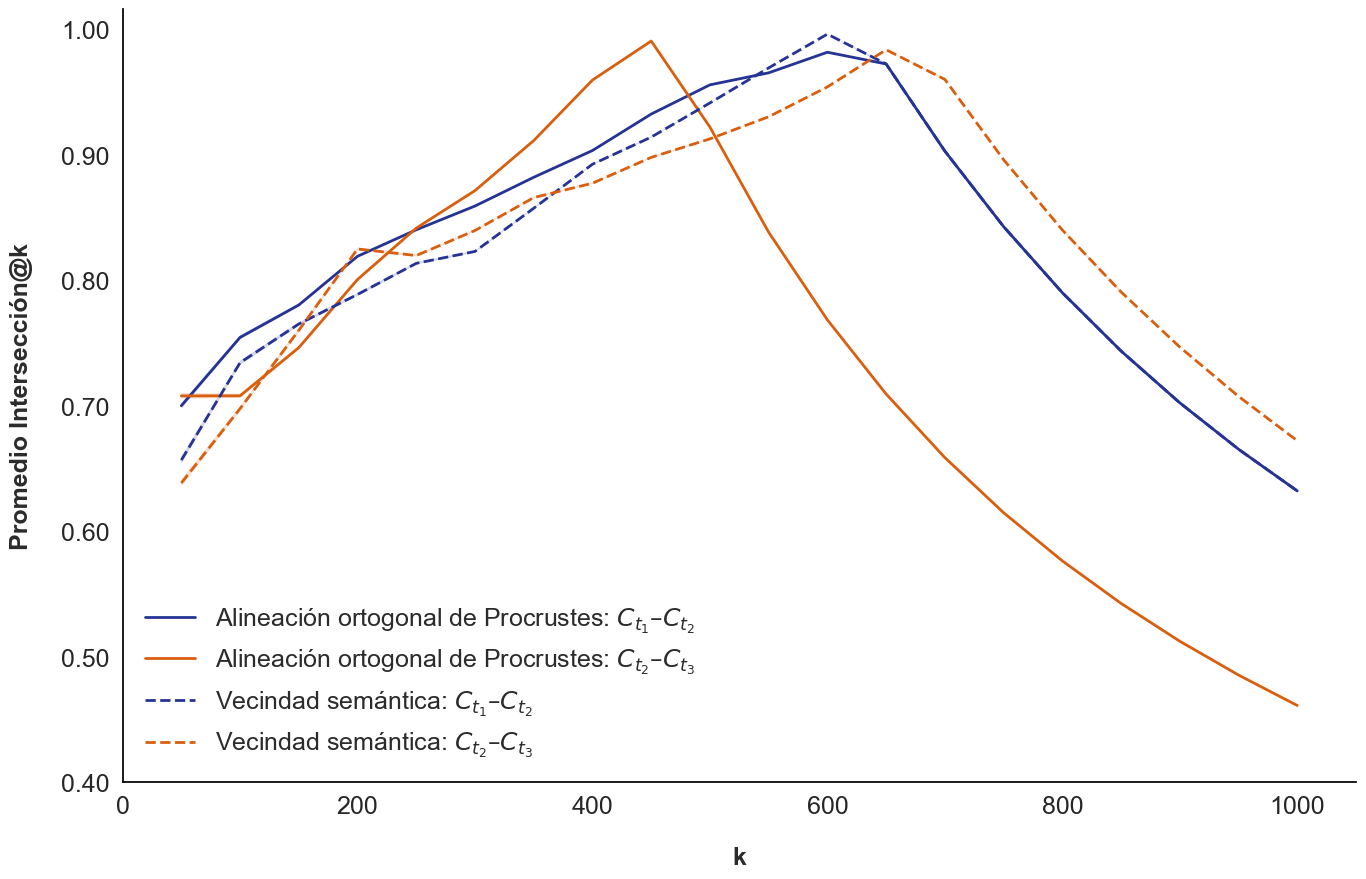

In [20]:
import ast
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(14, 10))

#  Color por período
period_colors = {
    '(2009, 2014)': '#253494',   # azul oscuro
    '(2014, 2019)': '#D95F0E'    # naranja intenso
}

period_labels = {
    '(2009, 2014)': r'$C_{t_1}$–$C_{t_2}$',
    '(2014, 2019)': r'$C_{t_2}$–$C_{t_3}$'
}

# ➖ Estilo por método

metodo_styles = {
    'Alineación ortogonal de Procrustes': '-',     # sólido
    'Vecindad semántica': '--'     # punteado
}

unique_metodos = sorted(estab_df['metodo'].unique())
unique_periodos = estab_df['periodo'].unique()

for metodo in unique_metodos:
    for periodo in unique_periodos:

        subdf = estab_df[
            (estab_df['metodo'] == metodo) &
            (estab_df['periodo'] == periodo)
        ].sort_values('k')

        if subdf.empty:
            continue

        X = subdf['k']
        Y = subdf['promedio interseccion k']

        y_lower = Y - subdf['ic_inferior'].replace(0, 0.001)
        y_upper = Y + subdf['ic_superior'].replace(0, 0.001)

        plt.plot(
            X, Y,
            linestyle=metodo_styles[metodo],
            linewidth=2,
            color=period_colors[periodo],
            label=f'{metodo}: {period_labels[periodo]}'  #  f'{metodo}: {ast.literal_eval(periodo)[0]} - {ast.literal_eval(periodo)[1]}'
        )

        plt.fill_between(
            X, y_lower, y_upper,
            color=period_colors[periodo],
            alpha=0.2,
            linewidth=0
        )

# Spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')


# Estética
ax.tick_params(axis='both', which='major', labelsize=18)
#ax.set_ylim(0, 1)
ax.set_ylim(0.40, estab_df['promedio interseccion k'].max() + 0.02)
ax.set_xlim(0, estab_df['k'].max() + 50)

ax.set_xlabel('k', fontsize=18, fontweight='bold', labelpad=20)
ax.set_ylabel('Promedio Intersección@k', fontsize=18, fontweight='bold', labelpad=20)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:.2f}")#.replace(",", "X").replace(".", ",").replace("X", "."))
)

plt.legend(fontsize=18, frameon=False)
plt.grid(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.savefig(
    BASE_DIR + 'imagenes/estabilidad_modelosAlineacion_IC.png',
    dpi=300, bbox_inches='tight',
    facecolor='white', edgecolor='none'
)

plt.show()



#### Figura 4.9

El valor óptimo de k se seleccionó con base en su máxima estabilidad global, entendida como la menor variación entre los valores máximo y mínimo del promedio Intersección@k a través de los enfoques y corpus comparados. Conforme a este criterio, se estableció k = 250
como valor de referencia para la detección de términos candidatos a cambio semántico en cada iteración, al presentar mayor estabilidad y elevada intersección promedio (>0,80) (veáse Figura 4.9 y Tabla 4.5)

In [34]:
# Agrupar por k y calcular el rango (max - min) de la métrica
rangos_k = (
    estab_df.groupby('k')['promedio interseccion k']
    .agg(['min', 'max'])
    .assign(rango=lambda d: d['max'] - d['min'])
    .reset_index()
)

rangos_k = rangos_k[rangos_k['k']<1000]
# Obtener el k con menor rango
k_menor_rango = rangos_k.loc[rangos_k['rango'].idxmin(), 'k']
rango_minimo = rangos_k['rango'].min()

print(f"El k con menor rango de 'promedio interseccion k' entre enfoques y períodos es: {k_menor_rango}")
print(f"Con un rango de: {rango_minimo:.6f}")

El k con menor rango de 'promedio interseccion k' entre enfoques y períodos es: 250
Con un rango de: 0.028069


In [32]:
rangos_k.sort_values('rango')

,k,min,max,rango
4,250,0.813401,0.841469,0.028069
2,150,0.746226,0.780201,0.033976
3,200,0.788612,0.824853,0.036241
9,500,0.912598,0.955669,0.043071
5,300,0.822887,0.871388,0.048501
6,350,0.857301,0.911249,0.053948
1,100,0.697608,0.754376,0.056767
0,50,0.638302,0.707755,0.069453
7,400,0.877259,0.959478,0.082218
8,450,0.897834,0.990587,0.092753


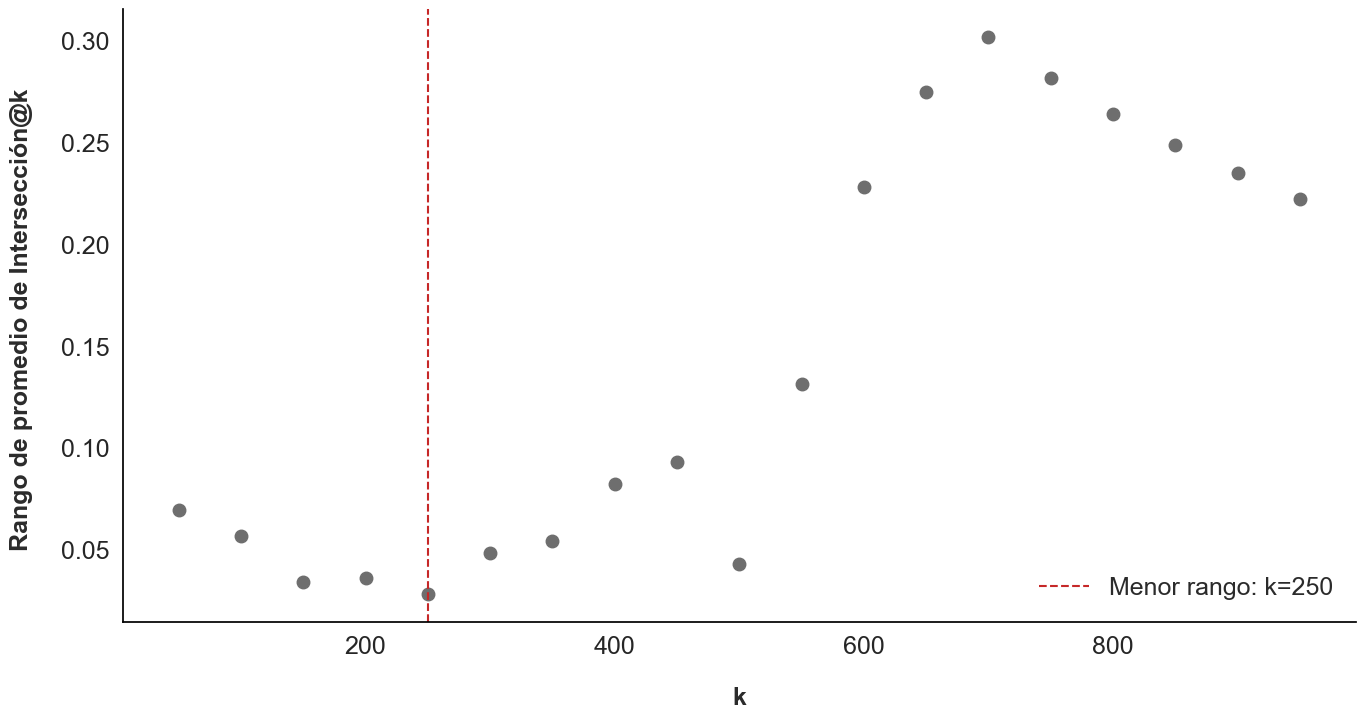

In [33]:

RED_HEALTH = "#C62828"
GRAY_LIGHT = "#6E6E6E"

plt.figure(figsize=(14,8))
plt.plot(rangos_k['k'], rangos_k['rango'], marker='o', label='', markersize=9, color = GRAY_LIGHT, linewidth=0)




plt.axvline(k_menor_rango, color=RED_HEALTH, linestyle='--', label=f'Menor rango: k={k_menor_rango}')
#plt.title('Rango de estabilidad  por valor de k',fontsize=14, fontweight='bold', pad=20)
plt.xlabel('k',fontsize=18, 
              fontweight='bold', 
              labelpad=20)
plt.ylabel('Rango de promedio de Intersección@k ', fontsize=18, 
              fontweight='bold', 
              labelpad=20)
plt.legend(frameon=False)
plt.grid(False)

# Spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:.2f}")#.replace(",", "X").replace(".", ",").replace("X", "."))
)
ax.tick_params(axis='both', which='major', labelsize=18)
# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/rango_estabilidadValorK.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
